# 03 · Pillar 3 — simulation storage, fast-PM & resimulation
OUF-Sim multi-backend storage (wrap-in-place vs re-encode + partial access), the fast-PM mini-sim (reproduces linear growth), and TreePM resimulation validated with field estimators. **Dummy/toy physics; the storage + orchestration substrate is real.**

In [1]:
%matplotlib inline
import os, sys, tempfile, warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, healpy as hp
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / 'test'))
TMP = Path(tempfile.mkdtemp())
DATA_ROOT='/home/ravoux/Documents/Science/Cosmography/oneuniverse_data'
EBOSS=Path(DATA_ROOT)/'spectroscopic/eboss/qso/DR16Q_Superset_v3.fits'
HAVE_EBOSS = EBOSS.exists()
print('real eBOSS data available:', HAVE_EBOSS)
from oneuniverse.simulation.cosmology import CosmologySpec
C = CosmologySpec(omega_m=0.31, omega_b=0.048, h=0.67, n_s=0.96, sigma8=0.81, t_cmb=2.7255)

/home/ravoux/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


real eBOSS data available: True


## Storage — wrap-in-place vs re-encode + partial-access pruning

In [2]:
from oneuniverse.simulation.linear import generate_linear_sim
from oneuniverse.simulation.linear.pack import write_packed_native
from oneuniverse.simulation.packed.converter import PackedSimConverter
from oneuniverse.simulation.oufsim import SimStore
from oneuniverse.simulation.selectors import Cube
lin = generate_linear_sim(TMP/'lin', C, box_size=256.0, n_grid=48, redshifts=(0.0,), seed=2, with_lightcone=False)
pk = write_packed_native(lin, TMP/'pk', particle_chunk_nside=4)
enc = PackedSimConverter().convert(pk, TMP/'enc', sim_name='d', projection='reencode')
ref = PackedSimConverter().convert(pk, TMP/'ref', sim_name='e', projection='reference')
sz=lambda p: sum(f.stat().st_size for f in p.rglob('*') if f.is_file())/1e6
store=SimStore(enc); store.read_box('snapshots',0.0,Cube(0,64,0,64,0,64))
print(f'store size  re-encode={sz(enc):.1f} MB  reference(wrap)={sz(ref):.1f} MB  ({100*sz(ref)/sz(enc):.0f}% of re-encode)')
print('partial-access read stats:', store.last_read_stats)

store size  re-encode=7.4 MB  reference(wrap)=1.0 MB  (14% of re-encode)
partial-access read stats: {'chunks_total': 64, 'chunks_read': 1, 'device': 'cpu', 'rank': 0, 'size': 1}


## Fast-PM mini-sim reproduces linear growth

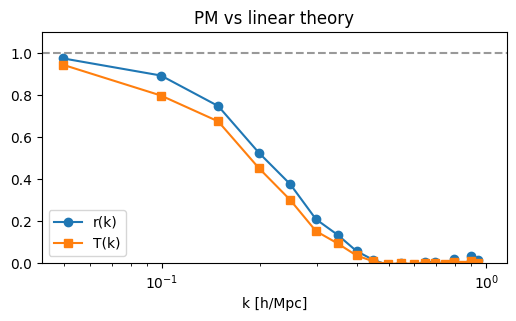

large-scale recovery: r=0.975  T=0.945


In [3]:
from oneuniverse.simulation.linear.gaussian_field import generate_density_field
from oneuniverse.simulation.pm.run import run_pm, zeldovich_pm_ic_from_field
from oneuniverse.simulation.pm.deposit import deposit_cic
from oneuniverse.simulation.validation import validate_field
BOX,N=256.0,48
ic = generate_density_field(C, box_size=BOX, n_grid=N, z=0.0, seed=2)
x,_ = run_pm(*zeldovich_pm_ic_from_field(C, ic, box=BOX, n_grid=N, z_start=9.0), box=BOX, n_grid=N, cosmo=C, a_start=0.1, a_end=1.0, n_steps=20)
d_pm = deposit_cic(x,N,BOX); d_pm = d_pm/d_pm.mean()-1
v = validate_field(d_pm, ic, box=BOX)
plt.figure(figsize=(6,3)); plt.semilogx(v.k, v.r, 'o-', label='r(k)'); plt.semilogx(v.k, v.transfer,'s-',label='T(k)')
plt.axhline(1,color='.6',ls='--'); plt.ylim(0,1.1); plt.xlabel('k [h/Mpc]'); plt.legend()
plt.title('PM vs linear theory'); plt.show()
print('large-scale recovery: r=%.3f  T=%.3f'%(np.nanmedian(v.r[v.k<0.06]), np.nanmedian(v.transfer[v.k<0.06])))

## Resimulation — TreePM-split beats the buffered baseline

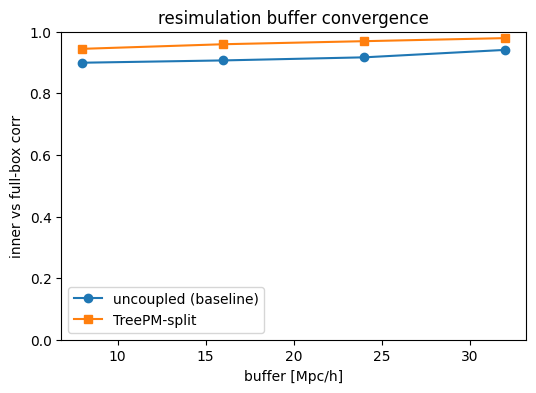

TreePM@8 (0.94) ≈ uncoupled@32 (0.94): same accuracy, 4× smaller buffer


In [4]:
from oneuniverse.simulation.resim.bench import reference_inner, uncoupled_resim_fn
from oneuniverse.simulation.resim.treepm import run_coupled_treepm
KW=dict(box=256.0,n_grid=48,target_lo=96.0,target_side=64.0,seed=2,n_steps=15)
rinner = reference_inner(C, **KW)
icf = generate_density_field(C, box_size=KW['box'], n_grid=KW['n_grid'], z=0.0, seed=KW['seed'])
unc = uncoupled_resim_fn(C, **KW)
tp = lambda b: run_coupled_treepm(C, icf, box=KW['box'], n_grid=KW['n_grid'], target_lo=KW['target_lo'], target_side=KW['target_side'], buffer=b, z_start=9.0, z_end=0.0, n_steps=KW['n_steps'])['inner']
co=lambda a: float(np.corrcoef(a.ravel(), rinner.ravel())[0,1])
buffers=[8.0,16.0,24.0,32.0]
cu=[co(unc(b)) for b in buffers]; ct=[co(tp(b)) for b in buffers]
plt.figure(figsize=(6,4)); plt.plot(buffers,cu,'o-',label='uncoupled (baseline)'); plt.plot(buffers,ct,'s-',label='TreePM-split')
plt.xlabel('buffer [Mpc/h]'); plt.ylabel('inner vs full-box corr'); plt.ylim(0,1); plt.legend()
plt.title('resimulation buffer convergence'); plt.show()
print('TreePM@8 (%.2f) ≈ uncoupled@32 (%.2f): same accuracy, 4× smaller buffer'%(ct[0],cu[-1]))

**Recap.** Storage substrate (multi-backend, index-only wrap, partial access) + fast-PM (linear growth recovered) + TreePM resimulation (beats the baseline) — all validated with field estimators.